In [1]:
import pandas as pd

hpa = pd.read_csv("../../data/AZ_harmonized_data/fact_expression_hpa.csv")  
print(hpa.shape)
print(hpa.columns.tolist())
hpa.head()

(24315372, 10)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'hugo_symbol', 'source', 'tpm', 'pTPM', 'nTPM', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,hugo_symbol,source,tpm,pTPM,nTPM,log2_tpm_plus1,is_expressed
0,ACH-001001,CVCL_2270,ENSG00000000003,TSPAN6,hpa,22.0,27.6,25.9,4.523562,True
1,ACH-000956,CVCL_1045,ENSG00000000003,TSPAN6,hpa,2.8,3.6,2.7,1.925999,True
2,ACH-000948,CVCL_1046,ENSG00000000003,TSPAN6,hpa,6.2,7.5,7.5,2.847997,True
3,ACH-000011,CVCL_7935,ENSG00000000003,TSPAN6,hpa,14.2,18.7,25.4,3.925999,True
4,ACH-000026,CVCL_7937,ENSG00000000003,TSPAN6,hpa,13.0,17.1,18.5,3.807355,True


In [2]:
print(hpa["source"].unique())

['hpa']


In [3]:
geo = pd.read_csv("../../data/AZ_harmonized_data/geo.csv")  
print(geo.shape)
print(geo.columns.tolist())
geo.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_120616\1781234455.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  geo = pd.read_csv("../../data/AZ_harmonized_data/geo.csv")


(65059038, 8)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'GSM_ID', 'source', 'tpm', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,GSM_ID,source,tpm,log2_tpm_plus1,is_expressed
0,ACH-000558,CVCL_0131,ENSG00000000003,GSM101610,geo,33.615700,5.113355,True
1,ACH-000558,CVCL_0131,ENSG00000000005,GSM101610,geo,40.925682,5.389762,True
2,ACH-000558,CVCL_0131,ENSG00000000419,GSM101610,geo,2182.281250,11.092282,True
3,ACH-000558,CVCL_0131,ENSG00000000457,GSM101610,geo,58.934814,5.905322,True
4,ACH-000558,CVCL_0131,ENSG00000000460,GSM101610,geo,136.418900,7.102437,True


In [4]:
# does one cell line have multiple GSM samples?
geo.groupby("ACH_ID")["GSM_ID"].nunique().sort_values(ascending=False).head()

ACH_ID
ACH-002875    108
ACH-001188     67
ACH-000019     49
ACH-000768     41
ACH-000681     31
Name: GSM_ID, dtype: int64

In [5]:
depmap = pd.read_csv("../../data/AZ_harmonized_data/fact_expression_depmap.csv")
print(depmap.shape)
print(depmap.columns.tolist())
depmap.head()

(80039310, 9)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'hugo_symbol', 'PR_ID', 'source', 'tpm', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,hugo_symbol,PR_ID,source,tpm,log2_tpm_plus1,is_expressed
0,ACH-001113,CVCL_5480,ENSG00000000005,TNMD,PR-AdBjpG,depmap,0.0,0.000000,False
1,ACH-001289,CVCL_RS25,ENSG00000000005,TNMD,PR-I2AzwG,depmap,0.5,0.584963,False
2,ACH-001339,CVCL_2408,ENSG00000000005,TNMD,PR-5ekAAC,depmap,0.0,0.000000,False
3,ACH-001538,CVCL_M261,ENSG00000000005,TNMD,PR-I21681,depmap,0.0,0.000000,False
4,ACH-000242,CVCL_0036,ENSG00000000005,TNMD,PR-i9DRP1,depmap,0.0,0.000000,False


In [6]:
# does one cell line have multiple PR Ids?
depmap.groupby("ACH_ID")["PR_ID"].nunique().sort_values(ascending=False).head()

ACH_ID
ACH-000029    2
ACH-000556    2
ACH-000328    2
ACH-000700    2
ACH-000517    2
Name: PR_ID, dtype: int64

In [7]:
# check the PR split 
print(depmap.groupby("ACH_ID")["PR_ID"].nunique().value_counts())

PR_ID
1    1463
2      16
Name: count, dtype: int64


In [8]:
print("depmap:", depmap.shape)
print("hpa:", hpa.shape)
print("geo:", geo.shape)

depmap: (80039310, 9)
hpa: (24315372, 10)
geo: (65059038, 8)


In [9]:
import numpy as np

for name, df, raw_col in [("depmap", depmap, "tpm"),
                          ("hpa",    hpa,    "tpm"),
                          ("geo",    geo,    "tpm")]:
    s = df.head(200000)
    diff = (np.log2(s[raw_col] + 1) - s["log2_tpm_plus1"]).abs().max()
    print(f"{name:7s} max diff = {diff}")

depmap  max diff = 8.881784197001252e-16
hpa     max diff = 1.7763568394002505e-15
geo     max diff = 1.7763568394002505e-15


In [10]:
target = "ENSG00000146648"   # EGFR

# pull the gene's rows from each source
dm_sub  = depmap[depmap["ensembl_id"] == target][["ACH_ID", "log2_tpm_plus1"]]
hpa_sub = hpa[hpa["ensembl_id"] == target][["ACH_ID", "log2_tpm_plus1"]]
geo_sub = geo[geo["ensembl_id"] == target][["ACH_ID", "log2_tpm_plus1"]]

# aggregate replicates per cell line
def aggregate_source(df, name, how="median"):
    agg = (df.groupby("ACH_ID")["log2_tpm_plus1"]
             .agg(value=how, spread="std", n_reps="count")
             .reset_index())
    agg["spread"] = agg["spread"].fillna(0)          # single replicate -> no spread
    agg["percentile"] = agg["value"].rank(pct=True) * 100
    agg = agg.rename(columns={
        "value":      f"{name}_value",
        "spread":     f"{name}_spread",
        "n_reps":     f"{name}_n_reps",
        "percentile": f"{name}_percentile",
    })
    return agg

dm_agg  = aggregate_source(dm_sub,  "depmap")
hpa_agg = aggregate_source(hpa_sub, "hpa")
geo_agg = aggregate_source(geo_sub, "geo")      # median matters most here

# one row per cell line, all three sources side by side
rna = dm_agg.merge(hpa_agg, on="ACH_ID", how="outer") \
            .merge(geo_agg, on="ACH_ID", how="outer")

print("Cell lines:", len(rna))
print("\nReplicates per cell line (max):")
for s in ["depmap", "hpa", "geo"]:
    col = f"{s}_n_reps"
    print(f"  {s:7s} max={rna[col].max():.0f}  mean={rna[col].mean():.2f}")

rna.head()

Cell lines: 1581

Replicates per cell line (max):
  depmap  max=2  mean=1.01
  hpa     max=8  mean=1.01
  geo     max=108  mean=4.10


,ACH_ID,depmap_value,depmap_spread,depmap_n_reps,depmap_percentile,hpa_value,hpa_spread,hpa_n_reps,hpa_percentile,geo_value,geo_spread,geo_n_reps,geo_percentile
0,ACH-000001,4.303781,0.0,1.0,52.805950,4.921246,0.0,1.0,62.262443,5.681323,0.891466,15.0,24.617997
1,ACH-000002,0.226509,0.0,1.0,18.864097,0.584963,0.0,1.0,22.760181,5.267464,0.215931,2.0,17.487267
2,ACH-000003,4.247168,0.0,1.0,51.656525,3.817623,0.0,1.0,43.122172,6.894469,0.819770,10.0,53.989813
3,ACH-000004,0.097611,0.0,1.0,8.012170,0.000000,0.0,1.0,2.081448,NaN,NaN,NaN,NaN
4,ACH-000005,0.097611,0.0,1.0,8.012170,0.137504,0.0,1.0,8.054299,5.247772,0.133200,2.0,16.808149


In [11]:
# Load harmonized proteomics data instead of the raw file
fact_prot = pd.read_csv("../../data/AZ_harmonized_data/fact_proteomics.csv")

print(fact_prot.shape)
print(fact_prot.columns.tolist())
fact_prot.head(10)

(4709250, 8)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'uniprot_id', 'hugo_symbol', 'protein_intensity', 'is_detected', 'z_score']


,ACH_ID,CVCL_ID,ensembl_id,uniprot_id,hugo_symbol,protein_intensity,is_detected,z_score
0,ACH-000849,CVCL_0419,ENSG00000163694,A0AV96,RBM47,0.358567,True,0.263468
1,ACH-000441,CVCL_1692,ENSG00000163694,A0AV96,RBM47,-1.112410,True,-0.808447
2,ACH-000248,CVCL_1074,ENSG00000163694,A0AV96,RBM47,0.855575,True,0.625642
3,ACH-000684,CVCL_2983,ENSG00000163694,A0AV96,RBM47,0.061377,True,0.046903
4,ACH-000856,CVCL_1110,ENSG00000163694,A0AV96,RBM47,0.284258,True,0.209318
5,ACH-000348,CVCL_1666,ENSG00000163694,A0AV96,RBM47,-0.485070,True,-0.351298
6,ACH-000062,CVCL_1655,ENSG00000163694,A0AV96,RBM47,0.092390,True,0.069502
7,ACH-000650,CVCL_2075,ENSG00000163694,A0AV96,RBM47,-0.824035,True,-0.598306
8,ACH-000484,CVCL_1790,ENSG00000163694,A0AV96,RBM47,0.926286,True,0.677170
9,ACH-000625,CVCL_0326,ENSG00000163694,A0AV96,RBM47,1.323508,True,0.966630


In [29]:
# protein percentile for the target gene 
prot = fact_prot[fact_prot["ensembl_id"] == target][["ACH_ID", "protein_intensity", "is_detected"]].copy()
prot = prot.dropna(subset=["protein_intensity"])
prot["protein_percentile"] = prot["protein_intensity"].rank(pct=True) * 100

combined = rna.merge(
    prot[["ACH_ID", "protein_intensity", "protein_percentile", "is_detected"]],
    on="ACH_ID", how="left"
)

# one confidence per RNA source, paired with protein
def pairing(df, source):
    rna_pct  = df[f"{source}_percentile"]
    prot_pct = df["protein_percentile"]

    has_rna  = rna_pct.notna()
    has_prot = prot_pct.notna()

    # strength: mean of the two percentiles where both exist, else RNA alone
    strength = np.where(has_prot, (rna_pct + prot_pct) / 2, rna_pct)

    # agreement: penalise RNA/protein disagreement. 1.0 when protein absent
    gap = (rna_pct - prot_pct).abs() / 100
    agreement = np.where(has_prot, 1 / (1 + gap), 1.0)

    # coverage: 1.0 with both evidence types, 0.5 with RNA only
    coverage = np.where(has_prot, 1.0, 0.75)

    conf = np.where(has_rna, coverage * agreement, np.nan)
    return pd.Series(strength, index=df.index).where(has_rna), pd.Series(conf, index=df.index)

for s in ["depmap", "hpa", "geo"]:
    combined[f"{s}_strength"], combined[f"{s}_conf"] = pairing(combined, s)

# GEO only: penalise inconsistent replicates (coefficient of variation)
geo_cv = combined["geo_spread"] / combined["geo_value"].replace(0, np.nan)
combined["geo_conf"] = combined["geo_conf"] * (1 / (1 + geo_cv.fillna(0)))

# combine the three pairings
strength_cols = [f"{s}_strength" for s in ["depmap", "hpa", "geo"]]
conf_cols     = [f"{s}_conf"     for s in ["depmap", "hpa", "geo"]]

combined["rna_percentile"]   = combined[strength_cols].mean(axis=1)
combined["n_sources"]        = combined[strength_cols].notna().sum(axis=1)
combined["source_std"]       = combined[strength_cols].std(axis=1).fillna(0)
combined["confidence_score"] = (
      (combined["n_sources"] / 3)
    * (1 / (1 + combined["source_std"] / 100))
    * combined[conf_cols].mean(axis=1)
)

combined = combined.sort_values(["rna_percentile", "confidence_score"], ascending=[False, False])
print(combined.shape)
combined[["ACH_ID", "rna_percentile", "n_sources", "source_std", "protein_intensity", "confidence_score"] + conf_cols].head(10)

(1581, 26)


,ACH_ID,rna_percentile,n_sources,source_std,protein_intensity,confidence_score,depmap_conf,hpa_conf,geo_conf
1235,ACH-001523,100.000000,1,0.000000,NaN,0.250000,0.750000,NaN,NaN
737,ACH-000741,99.937848,2,0.040087,5.154394,0.665572,0.999324,0.998193,NaN
633,ACH-000637,99.819525,2,0.127248,NaN,0.499365,0.750000,0.750000,NaN
1186,ACH-001411,99.797160,1,0.000000,NaN,0.250000,0.750000,NaN,NaN
1397,ACH-001864,99.661934,1,0.000000,NaN,0.250000,0.750000,NaN,NaN
1536,ACH-002680,99.459094,1,0.000000,NaN,0.250000,0.750000,NaN,NaN
1306,ACH-001649,99.391481,1,0.000000,NaN,0.250000,0.750000,NaN,NaN
1121,ACH-001328,99.312350,3,1.047457,NaN,0.724034,0.750000,0.750000,0.694854
470,ACH-000472,99.145073,3,0.334216,NaN,0.746309,0.750000,0.750000,0.746411
168,ACH-000170,99.141832,2,0.066198,NaN,0.499669,0.750000,0.750000,NaN


In [30]:
def score_with_penalty(rna_df, prot_df, penalty):
    df = rna_df.merge(
        prot_df[["ACH_ID", "protein_intensity", "protein_percentile", "is_detected"]],
        on="ACH_ID", how="left"
    )

    for source in ["depmap", "hpa", "geo"]:
        rna_pct  = df[f"{source}_percentile"]
        prot_pct = df["protein_percentile"]
        has_rna  = rna_pct.notna()
        has_prot = prot_pct.notna()

        strength  = np.where(has_prot, (rna_pct + prot_pct) / 2, rna_pct)
        gap       = (rna_pct - prot_pct).abs() / 100
        agreement = np.where(has_prot, 1 / (1 + gap), 1.0)
        coverage  = np.where(has_prot, 1.0, penalty)

        df[f"{source}_strength"] = pd.Series(strength, index=df.index).where(has_rna)
        df[f"{source}_conf"]     = pd.Series(coverage * agreement, index=df.index).where(has_rna)

    geo_cv = df["geo_spread"] / df["geo_value"].replace(0, np.nan)
    df["geo_conf"] = df["geo_conf"] * (1 / (1 + geo_cv.fillna(0)))

    s_cols = [f"{s}_strength" for s in ["depmap", "hpa", "geo"]]
    c_cols = [f"{s}_conf"     for s in ["depmap", "hpa", "geo"]]

    df["rna_percentile"]   = df[s_cols].mean(axis=1)
    df["n_sources"]        = df[s_cols].notna().sum(axis=1)
    df["source_std"]       = df[s_cols].std(axis=1).fillna(0)
    df["confidence_score"] = ((df["n_sources"] / 3)
                              * (1 / (1 + df["source_std"] / 100))
                              * df[c_cols].mean(axis=1))
    df["weighted_score"]   = df["rna_percentile"] * df["confidence_score"]
    return df

controls = {"ACH-001328": "A431", "ACH-000012": "HCC827", "ACH-000109": "NCIH3255"}

for p in [0.5, 0.75, 1.0]:
    scored = score_with_penalty(rna, prot, p).sort_values("weighted_score", ascending=False)
    scored = scored.reset_index(drop=True)
    print(f"\npenalty = {p}")
    for ach, name in controls.items():
        row = scored.index[scored["ACH_ID"] == ach]
        pos = row[0] + 1 if len(row) else None
        print(f"  {name:9s} rank {pos}")


penalty = 0.5
  A431      rank 129
  HCC827    rank 4
  NCIH3255  rank 6

penalty = 0.75
  A431      rank 34
  HCC827    rank 4
  NCIH3255  rank 6

penalty = 1.0
  A431      rank 4
  HCC827    rank 15
  NCIH3255  rank 17


In [39]:
combined["weighted_score"] = combined["rna_percentile"] * combined["confidence_score"]
combined.sort_values("weighted_score", ascending=False)[
    ["ACH_ID", "rna_percentile", "protein_intensity", "n_sources", "confidence_score", "weighted_score"]
].head(10)

,ACH_ID,rna_percentile,protein_intensity,n_sources,confidence_score,weighted_score
773,ACH-000777,98.415765,3.105255,3,0.964124,94.885004
689,ACH-000693,97.701336,3.443853,3,0.965849,94.364726
774,ACH-000778,95.832616,2.663723,3,0.961940,92.185252
10,ACH-000012,97.200804,2.724113,3,0.942916,91.652147
865,ACH-000869,96.602126,2.655742,3,0.938106,90.623071
107,ACH-000109,96.152664,2.465903,3,0.939454,90.331029
861,ACH-000865,94.439251,2.363419,3,0.933986,88.204980
532,ACH-000536,95.484826,2.873054,3,0.915966,87.460897
524,ACH-000528,92.656002,2.198802,3,0.938606,86.967491
845,ACH-000849,95.342117,2.649190,3,0.898613,85.675624


In [32]:
print(combined[["rna_percentile", "confidence_score"]].corr())

                  rna_percentile  confidence_score
rna_percentile          1.000000          0.019873
confidence_score        0.019873          1.000000


In [33]:
# load the cell line dictionary
dim = pd.read_csv("../../data/AZ_harmonized_data/dim_cell_lines.csv")
print(dim.columns.tolist())   # check the name column

['ach_id', 'cvcl_id', 'cell_line_name', 'ccle_name', 'primary_disease', 'Subtype', 'lineage', 'lineage_subtype', 'sex', 'age', 'primary_or_metastasis', 'sample_collection_site', 'growth_pattern', 'COSMICID', 'Sanger_Model_ID', 'source', 'metadata_source', 'profile_ids', 'n_profiles', 'has_real_name', 'has_full_metadata']


In [40]:
# merge names onto the ranking
named = combined.merge(
    dim[["ach_id", "cell_line_name", "primary_disease", "lineage"]],
    left_on="ACH_ID", right_on="ach_id", how="left"
)
named[["ACH_ID", "cell_line_name", "primary_disease", "lineage", "rna_percentile", "protein_intensity", "protein_percentile", 
       "n_sources", "confidence_score", "weighted_score"]].head(10)

,ACH_ID,cell_line_name,primary_disease,lineage,rna_percentile,protein_intensity,protein_percentile,n_sources,confidence_score,weighted_score
0,ACH-001523,HSC1,Skin Cancer,skin,100.000000,NaN,NaN,1,0.250000,25.000000
1,ACH-000741,UBLC1,Bladder Cancer,urinary_tract,99.937848,5.154394,100.0,2,0.665572,66.515874
2,ACH-000637,KYSE520,Esophageal Cancer,esophagus,99.819525,NaN,NaN,2,0.499365,49.846334
3,ACH-001411,UMUC5,Bladder Cancer,urinary_tract,99.797160,NaN,NaN,1,0.250000,24.949290
4,ACH-001864,YSCCC,Bile Duct Cancer,bile_duct,99.661934,NaN,NaN,1,0.250000,24.915483
5,ACH-002680,170MGBA,Brain Cancer,central_nervous_system,99.459094,NaN,NaN,1,0.250000,24.864773
6,ACH-001649,SHMAC5,Prostate Cancer,prostate,99.391481,NaN,NaN,1,0.250000,24.847870
7,ACH-001328,A431,Skin Cancer,skin,99.312350,NaN,NaN,3,0.724034,71.905518
8,ACH-000472,HSC2,Head and Neck Cancer,upper_aerodigestive,99.145073,NaN,NaN,3,0.746309,73.992890
9,ACH-000170,PRECLH,Non-Cancerous,prostate,99.141832,NaN,NaN,2,0.499669,49.538123


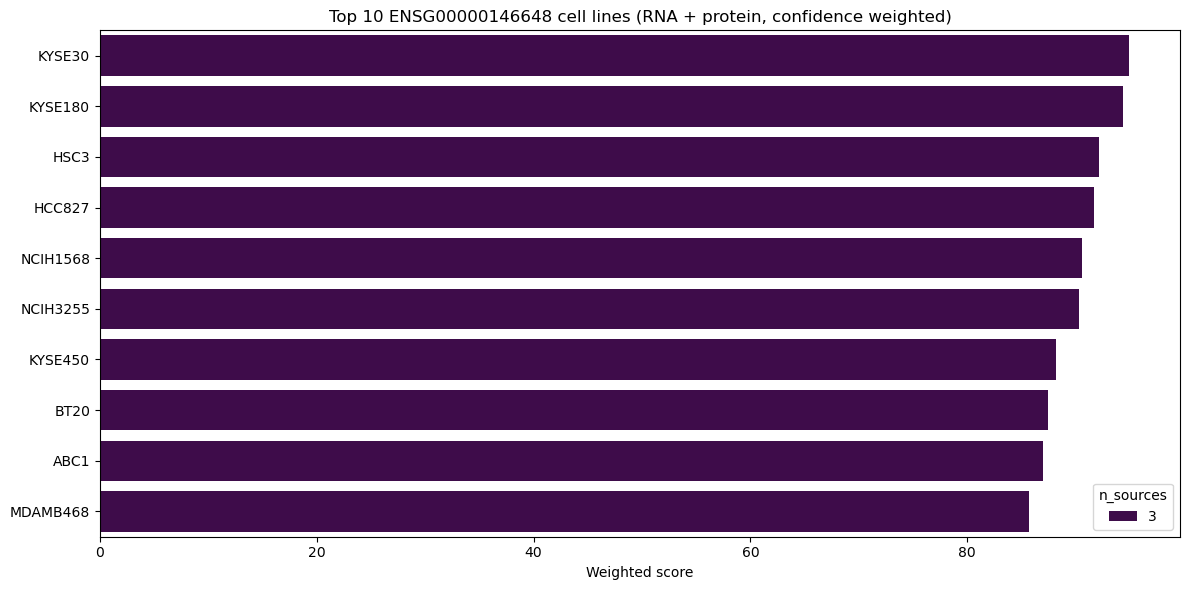

Saved to ../../processed/ENSG00000146648_composite_baseline.parquet


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10 = named.sort_values("weighted_score", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x="weighted_score", y="cell_line_name",
            hue="n_sources", palette="viridis", dodge=False)
plt.title(f"Top 10 {target} cell lines (RNA + protein, confidence weighted)")
plt.xlabel("Weighted score")
plt.ylabel("")
plt.tight_layout()
plt.show()

named.to_parquet(f"../../processed/{target}_composite_baseline.parquet")
print(f"Saved to ../../processed/{target}_composite_baseline.parquet")